In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
from tabulate import tabulate
from astropy.time import Time
from tqdm import tqdm
#from scipy.spatial.distance import pdist, squareforme
import numpy as np
from astropy.time import Time
import datetime
from collections import defaultdict
from scipy.spatial import cKDTree
import os
import glob
from collections import Counter


In [26]:
#loading in VLA coherent and incoherent files
df_coh = pd.read_pickle('/datax/scratch/ellambishop/test_refine/non_vlass_other.pkl')
df_incoh = pd.read_pickle('/datax/scratch/ellambishop/test_refine/non_vlass_incoherent.pkl')

columns = ['file_uri', 'observation_id','source_name', 'beam_id', 'ra_hours', 'dec_degrees', 'tstart',
               'signal_frequency', 'signal_beam', 'signal_drift_rate', 'signal_snr',
               'signal_power', 'signal_incoherent_power', 'signal_num_timesteps']
              # 'incoh_power', 'incoh_snr', 'freq_has_incoherent_counterpart', 'freq_has_phase_center_counterpart' ]
coh_df= df_coh[columns]
incoh_df = df_incoh[columns]

print(len(coh_df), len(incoh_df))

1942776 1342625


In [47]:

freq_tol = 1e-6        # frequency tolerance (same units as signal_frequency)
drift_tol = 1e-3       # drift tolerance (same units as signal_drift_rate)

# Ensure neat indexing
coh_df = coh_df.reset_index(drop=True)
incoh_df = incoh_df.reset_index(drop=True)

# Build scaled coordinate arrays: (freq/freq_tol, drift/drift_tol)
coh_coords = np.vstack([
    coh_df["signal_frequency"].values / freq_tol,
    coh_df["signal_drift_rate"].values / drift_tol
]).T

incoh_coords = np.vstack([
    incoh_df["signal_frequency"].values / freq_tol,
    incoh_df["signal_drift_rate"].values / drift_tol
]).T

tree = cKDTree(coh_coords)

# Query nearest coherent candidate for each incoherent entry (distance in scaled space)
dists, idxs = tree.query(incoh_coords, distance_upper_bound=1.0)

# Gather all potential matches within tolerance, with their true distances in original units if wanted
potential_matches = []
for incoh_idx, (dist_scaled, coh_idx) in enumerate(zip(dists, idxs)):
    if coh_idx == len(coh_df) or np.isinf(dist_scaled):
        continue
    # compute per-dimension absolute differences for possible tie-breaking/logging
    freq_diff = abs(incoh_df.loc[incoh_idx, "signal_frequency"] - coh_df.loc[coh_idx, "signal_frequency"])
    drift_diff = abs(incoh_df.loc[incoh_idx, "signal_drift_rate"] - coh_df.loc[coh_idx, "signal_drift_rate"])
    # keep the scaled distance for sorting; you can also store a combined metric

    potential_matches.append({
        "scaled_dist": dist_scaled,
        "coh_idx": int(coh_idx),
        "incoh_idx": int(incoh_idx),
        "freq_diff": float(freq_diff),
        "drift_diff": float(drift_diff),
        "snr_coh": float(coh_df.loc[coh_idx, "signal_snr"]) if "signal_snr" in coh_df.columns else np.nan,
        "snr_incoh": float(incoh_df.loc[incoh_idx, "signal_snr"]) if "signal_snr" in incoh_df.columns else np.nan
    })

# Sort by scaled distance (closest first). Optional secondary sort: prefer higher SNR.
potential_matches.sort(key=lambda x: (x["scaled_dist"], -x["snr_incoh"], -x["snr_coh"]))

# assign 1:1 by picking best (closest) matches first
used_coh = set()
used_incoh = set()
matched_pairs = []

for pm in potential_matches:
    coh_idx = pm["coh_idx"]
    incoh_idx = pm["incoh_idx"]
    if coh_idx in used_coh or incoh_idx in used_incoh:
        continue
    coh_row = coh_df.iloc[coh_idx]
    incoh_row = incoh_df.iloc[incoh_idx]

    pair = {
        'observation_id': coh_row.get('observation_id'),
        "ra_hours": coh_row.get('ra_hours'),
        "dec_degrees": coh_row.get('dec_degrees'),
        "file_uri": coh_row.get("file_uri"),
        "incoh_file": incoh_row.get("file_uri"),
        "signal_frequency": coh_row["signal_frequency"],
        "signal_beam": coh_row.get('signal_beam'),
        "signal_power": coh_row["signal_power"],
        "incoh_power": incoh_row["signal_power"],
        "power_ratio": coh_row["signal_power"] / incoh_row["signal_power"] if incoh_row["signal_power"] > 0 else np.nan,
        "tstart": coh_row.get("tstart"),
        "tstart_incoh": incoh_row.get("tstart"),
        "beam_id": coh_row.get("beam_id"),
        "beam_incoh": incoh_row.get("beam_id"),
        'signal_snr': coh_row.get('signal_snr'),
        'snr_incoh': incoh_row.get('signal_snr'),
        'signal_drift_rate': coh_row.get('signal_drift_rate'),
        'drift_incoh': incoh_row.get('signal_drift_rate'),
        'freq_diff': pm["freq_diff"],
        'drift_diff': pm["drift_diff"],
        'scaled_dist': pm["scaled_dist"]
    }

    matched_pairs.append(pair)
    used_coh.add(coh_idx)
    used_incoh.add(incoh_idx)

# Build DataFrame
matched_df = pd.DataFrame(matched_pairs)
matched_df['signal_frequency'] = matched_df['signal_frequency'].round(6)

# Unmatched sets for diagnostics
unmatched_coh = coh_df.drop(index=list(used_coh))
unmatched_incoh = incoh_df.drop(index=list(used_incoh))

# Stats
print("Coherent hits total:", len(coh_df))
print("Matched coherent hits:", len(used_coh))
print("Unmatched coherent hits:", len(unmatched_coh))
print("Incoherent hits total:", len(incoh_df))
print("Matched incoherent hits:", len(used_incoh))
print("Unmatched incoherent hits:", len(unmatched_incoh))

full_df = matched_df
# matched_df, unmatched_coh, unmatched_incoh are available for downstream use


Coherent hits total: 1942776
Matched coherent hits: 344525
Unmatched coherent hits: 1598251
Incoherent hits total: 1342625
Matched incoherent hits: 344525
Unmatched incoherent hits: 998100


/tmp/ipykernel_3617671/2887772918.py:8: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 100)  # zoom y-axis between ymin and ymax


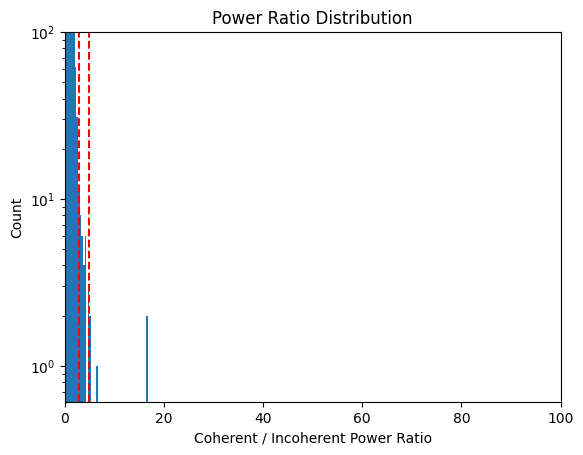

In [22]:
#compute power ratio with paired incoherent values

plt.hist(matched_df['power_ratio'], bins=50)
plt.yscale('log')
plt.axvline(3, color='r', linestyle='--')
plt.axvline(5, color='r', linestyle='--')
plt.xlim(0, 100)  # zoom x-axis between xmin and xmax
plt.ylim(0, 100)  # zoom y-axis between ymin and ymax
plt.xlabel('Coherent / Incoherent Power Ratio')
plt.ylabel('Count')
plt.title('Power Ratio Distribution')
plt.show()


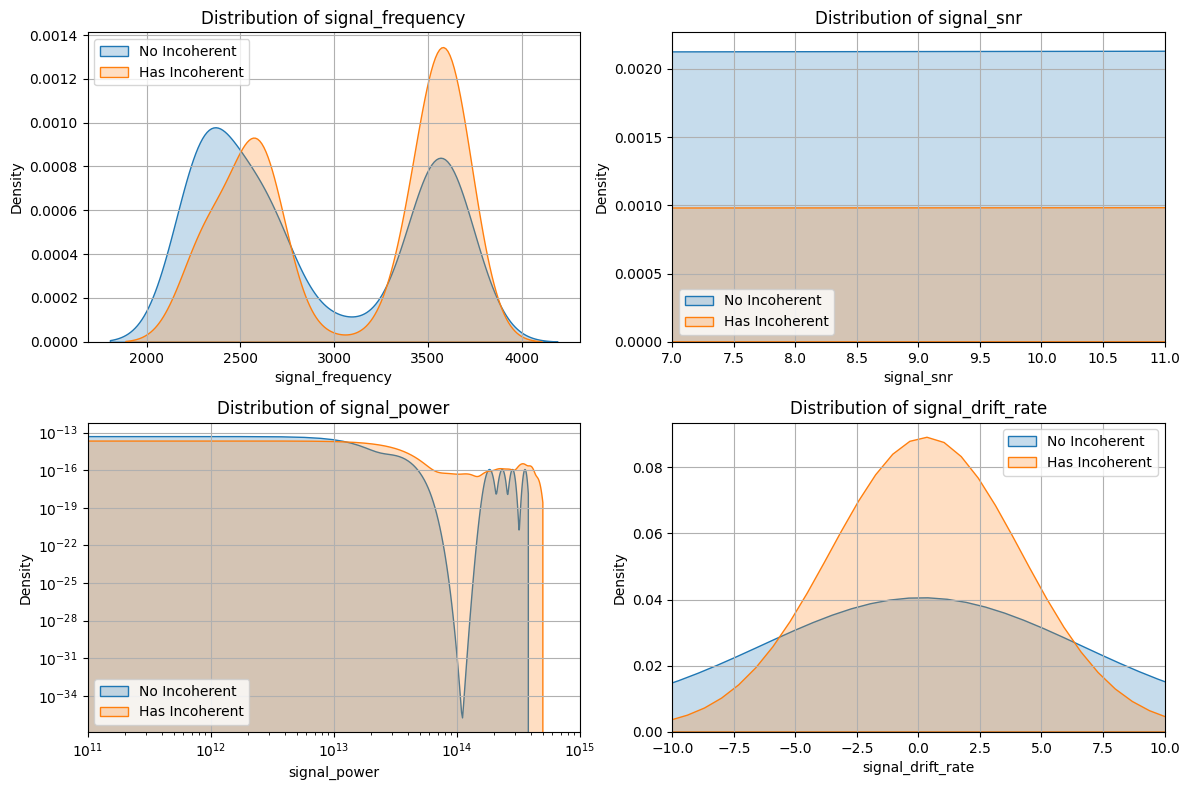

In [31]:
#visualizing differences between coherent and incoherent hits 
no_incoh_df = unmatched_coh
has_incoh_df = matched_df

features = ['signal_frequency', 'signal_snr', 'signal_power', 'signal_drift_rate']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    # Plot KDEs on each subplot
    sns.kdeplot(no_incoh_df[col].dropna(), label='No Incoherent', fill=True, ax=axes[i])
    sns.kdeplot(has_incoh_df[col].dropna(), label='Has Incoherent', fill=True, ax=axes[i])
    
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].grid(True)
    
    # Optional zooming and scaling
    if col == 'signal_snr':
        axes[i].set_xlim(7, 11)
    elif col == 'signal_power':
        axes[i].set_xscale('log')
        axes[i].set_xlim(1e11, 1e15)
        axes[i].set_yscale('log')
    elif col == 'signal_drift_rate':
        axes[i].set_xlim(-10, 10)

plt.tight_layout()
plt.show()

In [6]:
#gaia_df= pd.read_pickle('/datax/scratch/ellambishop/meerkat_hits/meerkat_gaia.pkl')
gaia_df= pd.read_pickle('/datax/scratch/ellambishop/meerkat_hits/meerkat_named.pkl')

def add_meerkat_config(df):
    df = df.copy() 
    df.loc[df['signal_frequency'] < 2000, 'config'] = 'MeerKAT'

add_meerkat_config(gaia_df)

In [48]:
#    Adds VLA configuration (config), date, and number of antennas to a dataframe based on tstart (MJD).
   # Expects df to contain a column 'tstart' in MJD format.
def add_vla_config(df):
 

    # --- Extended VLA configuration date ranges ---
    vla_config_ranges = [
        (datetime.date(2023, 1, 19), datetime.date(2023, 5, 29), 'B'),
        (datetime.date(2023, 6, 2),  datetime.date(2023, 6, 19), 'BnA'),
        (datetime.date(2023, 6, 30), datetime.date(2023, 10, 2), 'A'),
        (datetime.date(2023, 10, 3), datetime.date(2023, 10, 19), 'A'),
        (datetime.date(2023, 10, 20), datetime.date(2024, 1, 15), 'D'),
        (datetime.date(2024, 1, 16), datetime.date(2024, 1, 24), 'D'),   # patch
        (datetime.date(2024, 1, 25), datetime.date(2024, 5, 7), 'C'),
        (datetime.date(2024, 5, 8),  datetime.date(2024, 9, 16), 'B'),
        (datetime.date(2024, 9, 17), datetime.date(2024, 10, 7), 'BnA'),
        (datetime.date(2024, 10, 8), datetime.date(2025, 2, 3), 'A'),
        (datetime.date(2025, 2, 4), datetime.date(2025, 2, 24), 'A'),     # new patch
        (datetime.date(2025, 2, 25), datetime.date(2025, 5, 12), 'D'),
        (datetime.date(2025, 5, 13), datetime.date(2025, 5, 21), 'C'),    # patch
        (datetime.date(2025, 5, 22), datetime.date(2025, 8, 18), 'C'),
        (datetime.date(2025, 8, 19), datetime.date(2025, 9, 2), 'B'),     # patch
        (datetime.date(2025, 9, 3),  datetime.date(2026, 1, 20), 'B'),
    ]


    # Config → number of antennas (nominal value = 27)
    config_to_n_antennas = {
        'A': 27,
        'B': 27,
        'C': 27,
        'D': 27,
        'BnA': 27,
        'CnB': 27,
        'Unknown': np.nan
    }

    # Initialize new columns
    dates, configs, n_antennas_list = [], [], []

    for t in df['tstart']:
        try:
            time = Time(t, format='mjd')
            date_str = time.to_value('iso', subfmt='date')
            date_obj = datetime.datetime.strptime(date_str, "%Y-%m-%d").date()
            dates.append(date_str)

            matched_config = 'Unknown'
            for start, end, cfg in vla_config_ranges:
                if start <= date_obj <= end:
                    matched_config = cfg
                    break
            configs.append(matched_config)
            n_antennas_list.append(config_to_n_antennas.get(matched_config, np.nan))

        except Exception as e:
            print(f"[!] Error parsing tstart={t}: {e}")
            dates.append('Invalid')
            configs.append('Unknown')
            n_antennas_list.append(np.nan)

    # Update dataframe
    df = df.copy()
    df['date'] = dates
    df['config'] = configs
    df['n_antennas'] = n_antennas_list

    return df

#full_df = add_vla_config(full_df)
#print(full_df['config'].value_counts())
#print(full_df[['config', 'n_antennas']].drop_duplicates())

unmatched_coh = add_vla_config(unmatched_coh)
#print(unmatched_coh['config'].value_counts())
#print(unmatched_coh[['config', 'n_antennas']].drop_duplicates())


In [49]:
# calculate and assign the size of the beam for each hit 
def assign_beam_size_arcsec(full_df):
    import numpy as np

    # Beam size per band and configuration (arcsec)
    beam_resolutions = {
        'P' : {'MeerKAT': 13},
        'L':  {'MeerKAT': 13}, 
        'S':  {'D': 23, 'C': 7.0, 'B': 2.1, 'A': 0.65},
        'C':  {'D': 12, 'C': 3.5, 'B': 1.0, 'A': 0.33},
        'X':  {'D': 7.2, 'C': 2.1, 'B': 0.6, 'A': 0.20},
    }

    # Frequency bands in MHz
    conditions = [
        (full_df['signal_frequency'] >= 0)   & (full_df['signal_frequency'] < 850),
        (full_df['signal_frequency'] >= 850)  & (full_df['signal_frequency'] < 1800),
        (full_df['signal_frequency'] >= 2000) & (full_df['signal_frequency'] < 4000),
        (full_df['signal_frequency'] >= 4000) & (full_df['signal_frequency'] < 8000),
        (full_df['signal_frequency'] >= 8000) & (full_df['signal_frequency'] < 12000),
    ]
    band_labels = ['P', 'L', 'S', 'C', 'X']

    # Assign band
    full_df['band'] = np.select(conditions, band_labels, default='Unknown')

    # Default config if not present
    if 'config' not in full_df.columns:
        full_df['config'] = 'MeerKAT'

    # Create lookup dictionary
    beam_lookup = {
        (band, cfg): size
        for band, cfgs in beam_resolutions.items()
        for cfg, size in cfgs.items()
    }

    full_df['beam_key'] = list(zip(full_df['band'], full_df['config']))
    full_df['beam_size_arcsec'] = full_df['beam_key'].map(beam_lookup)

    return full_df


#full_df= assign_beam_size_arcsec(full_df)
unmatched_coh = assign_beam_size_arcsec(unmatched_coh)
#gaia_df = assign_beam_size_arcsec(gaia_df)

In [50]:
#split up hits based on the number of beams they were found in for specified analysis later on 

def split_and_combine_hits(df, time_col, fov_col, beam_max,
                           beam_col='signal_beam', freq_col='signal_frequency',
                           frequency_tol=1.0, drift_tol=0.1):

    df = df.copy()
    df['freq_bin'] = (df[freq_col] / frequency_tol).round().astype(int)
    df['drift_bin'] = (df['signal_drift_rate'] / drift_tol).round().astype(int)

    grouped_dfs = defaultdict(list)

    total_input_hits = len(df)
    total_hits_in_bins = 0
    total_hits_added = 0
    skipped_due_to_beammax = 0

    # Group only by time_col (e.g., tstart)
    for i, (time_val, group) in enumerate(df.groupby(time_col)):
        beam_counts = group.groupby(['freq_bin', 'drift_bin'])[beam_col].nunique()

        for (freq_bin, drift_bin), n_beams in beam_counts.items():
            hits_in_bin = group[
                (group['freq_bin'] == freq_bin) &
                (group['drift_bin'] == drift_bin)
            ]

            total_hits_in_bins += len(hits_in_bin)

            if n_beams > beam_max:
                skipped_due_to_beammax += len(hits_in_bin)
                continue

            # Assign bins to groups: 1-2, 3-5, and 6-up
            if n_beams <= 2:
                key = '1_2_beams'
            elif 3 <= n_beams <= 5:
                key = '3_5_beams'
            else:  # 6 or more up to beam_max
                key = '6_plus_beams'

            grouped_dfs[key].append(hits_in_bin)
            total_hits_added += len(hits_in_bin)

    # Concatenate groups
    for key in grouped_dfs:
        grouped_dfs[key] = pd.concat(grouped_dfs[key], ignore_index=True)

    def get_beam_group(key):
        g = grouped_dfs.get(key, [])
        return [g] if isinstance(g, pd.DataFrame) else g

    beams_1_2 = get_beam_group('1_2_beams')
    beams_3_5 = get_beam_group('3_5_beams')
    beams_6_plus = get_beam_group('6_plus_beams')

    df_1_2 = pd.concat(beams_1_2, ignore_index=True) if beams_1_2 else pd.DataFrame()
    df_3_5 = pd.concat(beams_3_5, ignore_index=True) if beams_3_5 else pd.DataFrame()
    df_6_plus = pd.concat(beams_6_plus, ignore_index=True) if beams_6_plus else pd.DataFrame()

    print(f"Total hits in input df: {total_input_hits}")
    print(f"Total hits inside freq/drift bins: {total_hits_in_bins}")
    print(f"Total hits added (passed beam_max filter): {total_hits_added}")
    print(f"Total hits skipped due to beam_max filter: {skipped_due_to_beammax}")
    print(f"Hits lost for other reasons: {total_input_hits - total_hits_in_bins}")

    return df_1_2, df_3_5, df_6_plus

In [51]:
'''
# MeerKAT 
df_1_2_beam_meer, df_3_4_5_beam_meer, df_6_beam_meer = split_and_combine_hits(
    gaia_df,
    time_col='tstart',
    fov_col='source_name',
    beam_max=45,
    beam_col='beam_id',
    freq_col='signal_frequency',
    frequency_tol=1.0, 
    drift_tol=0.5
)

#VLA
df_1_2_beam_vla, df_3_4_5_beam_vla, df_6 = split_and_combine_hits(
    full_df,
    time_col='tstart',
    fov_col='file_uri',
    beam_max=5,
    beam_col='beam_id',
    freq_col='signal_frequency'
)
'''
#VLA unmatched 
df_1_2_beam_vla_unmatched, df_3_4_5_beam_vla_unmatched , df_6_unamtched  = split_and_combine_hits(
    unmatched_coh,
    time_col='tstart',
    fov_col='file_uri',
    beam_max=5,
    beam_col='beam_id',
    freq_col='signal_frequency'
)


print(len(df_1_2_beam_vla_unmatched), len(df_3_4_5_beam_vla_unmatched) , len(df_6_unamtched))
#print(len(df_1_2_beam_vla), len(df_3_4_5_beam_vla), len(df_6))
#print(len(df_1_2_beam_meer), len(df_3_4_5_beam_meer), len(df_6_beam_meer)) 

Total hits in input df: 1598251
Total hits inside freq/drift bins: 1598251
Total hits added (passed beam_max filter): 1597580
Total hits skipped due to beam_max filter: 671
Hits lost for other reasons: 0
390899 1206681 0


In [52]:
#flag overlapping signals in spacially separated beams as rfi, same file uri/fov 
def flag_local_rfi(df, field, area_multiplier=3, beam_threshold_fraction=0.75, drift_tol=1.0):
    from scipy.spatial import ConvexHull
    import numpy as np

    local_flag_count = 0
    df['rfi_flag_local'] = False

    df['drift_bin'] = (df['signal_drift_rate'] / drift_tol).round().astype(int)

    freq_drift_combos = df.groupby(['signal_frequency', 'drift_bin'])

    # ⚡ Precompute beam counts per FOV
    beam_count_by_fov = df.groupby(field)['signal_beam'].nunique().to_dict()

    for (freq,drift_bin), combo_group in freq_drift_combos:
        #freq_subset = df[df['signal_frequency'] == freq]

        for fov in combo_group[field].unique():
            subset = combo_group[combo_group[field] == fov]
            unique_beams = subset['signal_beam'].unique()

            total_beams = beam_count_by_fov.get(fov, 0)
            min_required_beams = max(3, int(beam_threshold_fraction * total_beams))

            if len(unique_beams) < min_required_beams or len(subset) < 3:
                continue

            ra0, dec0 = np.mean(subset['ra_hours']), np.mean(subset['dec_degrees'])
            ra_offsets = (subset['ra_hours'] - ra0) * 3600 * np.cos(np.deg2rad(dec0))
            dec_offsets = (subset['dec_degrees'] - dec0) * 3600
            points = np.vstack([ra_offsets, dec_offsets]).T

            try:
                hull = ConvexHull(points)
                hit_area = hull.area
            except:
                hit_area = 0

            avg_beam_size = subset['beam_size_arcsec'].mean()
            beam_area = np.pi * (avg_beam_size / 2)**2
            threshold_area = area_multiplier * beam_area

            if hit_area > threshold_area:
                df.loc[subset.index, 'rfi_flag_local'] = True
                local_flag_count += len(subset)

    return df, local_flag_count



In [53]:
#flagging frequencies and drift rates found in same place at dif times/ time persistent rfi 
def flag_temporal_persistence_rfi(df,
                                   frequency_tol=1.0,
                                   drift_tol=1.0,
                                   radius_multiplier=3,
                                   min_time_gap=10,  # seconds
                                   min_repeat_count=2,
                                   debug=False):
    df = df.copy()
    df['rfi_flag_global'] = False

    df['freq_bin'] = (df['signal_frequency'] / frequency_tol).round().astype(int)
    df['drift_bin'] = (df['signal_drift_rate'] / drift_tol).round().astype(int)

    dec_mean = df['dec_degrees'].mean()
    df['ra_arcsec'] = df['ra_hours'] * 3600 * np.cos(np.deg2rad(dec_mean))
    df['dec_arcsec'] = df['dec_degrees'] * 3600

    flagged_indices = set()
    grouped = df.groupby(['freq_bin', 'drift_bin'])

    for (f_bin, d_bin), group in grouped:
        if len(group) < min_repeat_count:
            continue

        coords = group[['ra_arcsec', 'dec_arcsec']].values
        beam_sizes = group['beam_size_arcsec'].values
        times = group['tstart_datetime'].values
        tree = cKDTree(coords)

        for i in range(len(group)):
            r_i = radius_multiplier * beam_sizes[i]
            time_i = times[i]

            idx_neighbors = tree.query_ball_point(coords[i], r=r_i)
            repeat_times = []

            for j in idx_neighbors:
                if i == j:
                    continue
                time_j = times[j]
                time_diff = abs(pd.Timedelta(time_i - time_j).total_seconds())
                if time_diff >= min_time_gap:
                    repeat_times.append(group.index[j])

            if len(set(repeat_times)) >= (min_repeat_count - 1):
                flagged_indices.add(group.index[i])
                flagged_indices.update(repeat_times)

    df.loc[list(flagged_indices), 'rfi_flag_global'] = True
    return df, len(flagged_indices)

In [54]:
#multi beam matched 
def flag_global_freq_repeats(df, freq_col='signal_frequency', drift_col='signal_drift_rate', time_col='tstart', flag_col='rfi_flag_global'):


    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        print("[!] Skipping: DataFrame is None or empty.")
        return df

    # Group by frequency + drift and count unique FOVs
    repeat_groups = df.groupby([freq_col, drift_col])[time_col].nunique()

    # Identify freq/drift pairs that appear in more than one FOV
    suspect_freqs = repeat_groups[repeat_groups > 1].index

    # Mark rows with global frequency repeats
    df['global_freq_repeat'] = df.set_index([freq_col, drift_col]).index.isin(suspect_freqs)

    # Initialize or update flag_strength
    if 'flag_strength' not in df.columns:
        df['flag_strength'] = 0
    df.loc[df['global_freq_repeat'], 'flag_strength'] += 1

    # Print summary
    if flag_col in df.columns:
        print(f"Temporal persistence global RFI flagged: {df[flag_col].sum()}")
    print(f"Multi-FOV freq+drift repeats flagged: {df['global_freq_repeat'].sum()}")

    return df


In [55]:

def safe_mjd_to_datetime(mjd_series, min_mjd=40000, max_mjd=80000):
    # Coerce non-numeric values to NaN
    mjd_series = pd.to_numeric(mjd_series, errors='coerce')
    
    # Only keep plausible MJDs
    valid_mask = (mjd_series >= min_mjd) & (mjd_series <= max_mjd)
    
    out = pd.Series(pd.NaT, index=mjd_series.index)
    if valid_mask.any():
        out.loc[valid_mask] = Time(mjd_series.loc[valid_mask], format='mjd').to_datetime()
    return out

def call_func(df, title):
    if isinstance(df, pd.DataFrame) and not df.empty:
        print(f"Processing {title}...")

        # Safe MJD → datetime
        df['tstart_datetime'] = safe_mjd_to_datetime(df['tstart'])

        # Initialize flags
        df['rfi_flag_global'] = False
        df['rfi_flag_local'] = False

        # Run local and global RFI flagging
        df, local_count = flag_local_rfi(df, 'file_uri')
        df, global_count = flag_temporal_persistence_rfi(df)
        print(f"Global RFI flagged: {global_count}")

        # Additional global frequency repeat check
        df = flag_global_freq_repeats(df)

        return local_count, global_count, df
    else:
        print(f"{title} is missing or empty; skipping local RFI flagging.")
        return 0, 0, df


In [56]:
local_count_unmatched, global_count_unmatched, unmatched_coh = call_func(df_3_4_5_beam_vla_unmatched, "unmatched_coh")

#meer = pd.concat([df_6_beam_meer, df_3_4_5_beam_meer], ignore_index=True)

#ocal_count_meer, global_count_meer, meerkat_df = call_func(meer, "meerkat_df")

#local_count_vla, global_count_vla, df_3_4_5_beam_vla = call_func(df_3_4_5_beam_vla, "df_3_4_5_beam_vla")

Processing unmatched_coh...


KeyboardInterrupt: 

In [ ]:
#set all flags within the df 
def apply_rfi_flagging(df, local_count=None, global_count=None,
                       apply_spatial_flags=True,
                       apply_power_ratio_flag=True,
                       missing_power=True, 
                       unmatched = False,
                       debug=False) :
    if local_count is not None:
        print(f"Local RFI flagged:  {local_count}")
    if global_count is not None:
        print(f"Global RFI flagged: {global_count}")

    # Ensure required flag columns exist and are boolean
    required_bool_cols = [
        'rfi_flag_local', 'rfi_flag_global', 'global_freq_repeat',
        'freq_has_incoherent_counterpart', 'freq_has_phase_center_counterpart'
    ]
    for col in required_bool_cols:
        if col not in df.columns:
            df[col] = False
        df[col] = df[col].fillna(False).astype(bool)

    # Ensure power_ratio exists
    if 'power_ratio' not in df.columns:
        df['power_ratio'] = np.nan

    # Flag for missing power ratio
    df["rfi_flag_missing_power_ratio"] = df["power_ratio"].isna()

    # Initialize main flags
    df['rfi_flag'] = False
    df['rfi_flag'] = df['rfi_flag'].astype(bool)
    df['flag_strength'] = 0

    stage_counts = {}
    stage_counts['initial'] = len(df)

    # --- Spatial flags ---
    if apply_spatial_flags:
        # Local flag
        df.loc[df['rfi_flag_local'], 'rfi_flag'] = True
        df.loc[df['rfi_flag_local'], 'flag_strength'] += 1
        stage_counts['after_local_flag'] = (~df['rfi_flag']).sum()

        # Global only (global but not local)
        global_only = df['rfi_flag_global'] & (~df['rfi_flag_local'])
        df.loc[global_only, 'rfi_flag'] = True
        df.loc[global_only, 'flag_strength'] += 1
        stage_counts['after_global_only_flag'] = (~df['rfi_flag']).sum()

    # --- Power ratio flags ---
    if apply_power_ratio_flag:
        cond_power = df['power_ratio'].notna() & ((df['power_ratio'] < 3) | (df['power_ratio'] > 5))
        df.loc[cond_power, 'rfi_flag'] = True
        df.loc[cond_power, 'flag_strength'] += 2
        stage_counts['after_cond2'] = (~df['rfi_flag']).sum()

    # --- Global repeat flags ---
    df['global_freq_repeat'] = df['global_freq_repeat'].fillna(False).astype(bool)
    df.loc[df['global_freq_repeat'], 'rfi_flag'] = True
    df.loc[df['global_freq_repeat'], 'flag_strength'] += 1
    stage_counts['after_global_repeat'] = (~df['rfi_flag']).sum()

    # --- Missing power ratio flags ---
    if missing_power:
        df.loc[df['rfi_flag_missing_power_ratio'], 'rfi_flag'] = True
        df.loc[df['rfi_flag_missing_power_ratio'], 'flag_strength'] += 1
        stage_counts['after_missing_power_ratio'] = (~df['rfi_flag']).sum()

    if unmatched:
        cond_unmatched_mask = df['signal_snr'] < 50
        df.loc[cond_unmatched_mask, 'rfi_flag'] = True
        df.loc[cond_unmatched_mask, 'flag_strength'] += 2
        stage_counts['after_unmatched_upper_threshold'] = (~df['rfi_flag']).sum()

    if debug:
        print("Counts for conditions:")
        print(f"cond2 (power ratio outside [3,5]): {cond_power.sum() if apply_power_ratio_flag else 0}")
        print(f"global_only (global but not local): {global_only.sum() if apply_spatial_flags else 0}")
        print(f"global_freq_repeat: {df['global_freq_repeat'].sum()}")
        print(f"Missing power ratio: {df['rfi_flag_missing_power_ratio'].sum()}")
        print("\n")

    return df, stage_counts


In [ ]:
def process_and_split_rfi(
    df_1_2_beam=None,
    df_3_4_5_beam=None,
    local_count=None,
    global_count=None,
    include_multi_beam=True,
    gaia=True,
    unmatched= False     
):
    def split_by_flag_strength(df, clean_thresh=0, maybe_thresh=1):
        clean_df = df[df['flag_strength'] <= clean_thresh]
        maybe_rfi_df = df[(df['flag_strength'] > clean_thresh) & (df['flag_strength'] <= maybe_thresh)]
        strong_rfi_df = df[df['flag_strength'] > maybe_thresh]
        return clean_df, maybe_rfi_df, strong_rfi_df

    stage_counts_3_4_5 = None
    stage_count_1_2 = None

    if gaia:
        apply_power_ratio_flag_1_2 = False
        apply_power_ratio_flag_3_4_5 = False
    else:
        apply_power_ratio_flag_1_2 = False
        apply_power_ratio_flag_3_4_5 = True

    # Multi-beam
    if include_multi_beam and isinstance(df_3_4_5_beam, pd.DataFrame) and not df_3_4_5_beam.empty:
        df_multi_beam, stage_counts_3_4_5 = apply_rfi_flagging(
            df_3_4_5_beam,
            local_count=local_count,
            global_count=global_count,
            apply_spatial_flags=True,
            apply_power_ratio_flag=apply_power_ratio_flag_3_4_5,
            missing_power=apply_power_ratio_flag_3_4_5,
            unmatched=unmatched,
            debug=False,
        )

    else:
        df_multi_beam = pd.DataFrame()

    # Single-beam
    if isinstance(df_1_2_beam, pd.DataFrame) and not df_1_2_beam.empty:
        for col in [
            'rfi_flag_local', 'rfi_flag_global',
            'global_freq_repeat', 'freq_has_incoherent_counterpart',
            'freq_has_phase_center_counterpart'
        ]:
            if col not in df_1_2_beam.columns:
                df_1_2_beam[col] = False

        df_single_beam, stage_count_1_2 = apply_rfi_flagging(
            df_1_2_beam,
            apply_spatial_flags=False,
            apply_power_ratio_flag=apply_power_ratio_flag_1_2,
            missing_power=apply_power_ratio_flag_1_2,  # ONLY if power ratio flagging is enabled
            unmatched=unmatched,
            debug=False
        )

    else:
        df_single_beam = pd.DataFrame()

    # Combine
    if include_multi_beam:
        fin_df = pd.concat([df_single_beam, df_multi_beam], ignore_index=True)
    else:
        fin_df = df_single_beam.copy()
    # Split
    clean_df, maybe_rfi_df, strong_rfi_df = split_by_flag_strength(fin_df)

    # Summary
    print("\n=== Summary ===")
    print(f"Likely clean (flag_strength ≤ 0): {len(clean_df)}")
    print(f"Maybe RFI (flag_strength == 1):   {len(maybe_rfi_df)}")
    print(f"Strong RFI (flag_strength > 1):  {len(strong_rfi_df)}")
    if len(fin_df) > 0:
        print(f"Percentage clean: {100 * len(clean_df) / len(fin_df):.2f}%")

    return clean_df, maybe_rfi_df, strong_rfi_df, stage_count_1_2, stage_counts_3_4_5



In [ ]:
def process_and_split_rfi(
    df_1_2_beam=None,
    df_3_4_5_beam=None,
    local_count=None,
    global_count=None,
    include_multi_beam=True,
    gaia=True,
    unmatched=False     
):
    def split_by_flag_strength(df, clean_thresh=0, maybe_thresh=1):
        clean_df = df[df['flag_strength'] <= clean_thresh]
        maybe_rfi_df = df[(df['flag_strength'] > clean_thresh) & (df['flag_strength'] <= maybe_thresh)]
        strong_rfi_df = df[df['flag_strength'] > maybe_thresh]
        return clean_df, maybe_rfi_df, strong_rfi_df

    stage_counts_3_4_5 = None
    stage_count_1_2 = None

    # Decide whether to apply power ratio flags
    if gaia:
        apply_power_ratio_flag_1_2 = False
        apply_power_ratio_flag_3_4_5 = False
    else:
        apply_power_ratio_flag_1_2 = False
        apply_power_ratio_flag_3_4_5 = True

    # Multi-beam
    if include_multi_beam and isinstance(df_3_4_5_beam, pd.DataFrame) and not df_3_4_5_beam.empty:
        df_multi_beam, stage_counts_3_4_5 = apply_rfi_flagging(
            df_3_4_5_beam,
            local_count=local_count,
            global_count=global_count,
            apply_spatial_flags=True,
            apply_power_ratio_flag=apply_power_ratio_flag_3_4_5,
            missing_power=apply_power_ratio_flag_3_4_5,
            unmatched=unmatched,
            debug=False,
        )
    else:
        df_multi_beam = pd.DataFrame()

    # Single-beam
    if isinstance(df_1_2_beam, pd.DataFrame) and not df_1_2_beam.empty:
        # Ensure required columns exist
        for col in [
            'rfi_flag_local', 'rfi_flag_global',
            'global_freq_repeat', 'freq_has_incoherent_counterpart',
            'freq_has_phase_center_counterpart'
        ]:
            if col not in df_1_2_beam.columns:
                df_1_2_beam[col] = False

        df_single_beam, stage_count_1_2 = apply_rfi_flagging(
            df_1_2_beam,
            apply_spatial_flags=False,
            apply_power_ratio_flag=apply_power_ratio_flag_1_2,
            missing_power=apply_power_ratio_flag_1_2,
            unmatched=unmatched,
            debug=False
        )
    else:
        df_single_beam = pd.DataFrame()

    # Combine both datasets
    if include_multi_beam:
        fin_df = pd.concat([df_single_beam, df_multi_beam], ignore_index=True)
    else:
        fin_df = df_single_beam.copy()

    # Split by RFI likelihood
    clean_df, maybe_rfi_df, strong_rfi_df = split_by_flag_strength(fin_df)

    # Summary printout
    print("\n=== Summary ===")
    print(f"Likely clean (flag_strength ≤ 0): {len(clean_df)}")
    print(f"Maybe RFI (flag_strength == 1):   {len(maybe_rfi_df)}")
    print(f"Strong RFI (flag_strength > 1):  {len(strong_rfi_df)}")
    if len(fin_df) > 0:
        print(f"Percentage clean: {100 * len(clean_df) / len(fin_df):.2f}%")

    # Merge stage counts into a single dict for plotting
    combined_stage_counts = {}
    if stage_count_1_2:
        combined_stage_counts.update({f"1_2_{k}": v for k, v in stage_count_1_2.items()})
    if stage_counts_3_4_5:
        combined_stage_counts.update({f"3_4_5_{k}": v for k, v in stage_counts_3_4_5.items()})

    return clean_df, maybe_rfi_df, strong_rfi_df, combined_stage_counts


In [ ]:
'''
clean_df, maybe_rfi_df, strong_rfi_df, combined_stage_counts = process_and_split_rfi(
    df_1_2_beam=df_1_2_beam_vla,
    df_3_4_5_beam=df_3_4_5_beam_vla,
    local_count=local_count_vla,
    global_count=global_count_vla,
    include_multi_beam=True,
)
'''
clean_unmatched_df, maybe_rfi_unmatched_df, strong_rfi_unmatched_df,combined_stage_counts_unmatched  = process_and_split_rfi(
    df_1_2_beam=df_1_2_beam_vla_unmatched,
    df_3_4_5_beam=df_3_4_5_beam_vla_unmatched,
    local_count=local_count_unmatched,
    global_count=global_count_unmatched,
    include_multi_beam=True,
     unmatched =True
)
'''
clean_meer_df, maybe_rfi_meer_df, strong_rfi_meer_df, combined_stage_counts_meer = process_and_split_rfi(
    df_1_2_beam=df_1_2_beam_meer,
    df_3_4_5_beam=meerkat_df,
    local_count=local_count_meer,
    global_count=global_count_meer,
    include_multi_beam=True, 
    gaia= True
)
'''

Local RFI flagged:  3
Global RFI flagged: 130562

=== Summary ===
Likely clean (flag_strength ≤ 0): 213951
Maybe RFI (flag_strength == 1):   130565
Strong RFI (flag_strength > 1):  0
Percentage clean: 62.10%


'\nclean_unmatched_df, maybe_rfi_unmatched_df, strong_rfi_unmatched_df,combined_stage_counts_unmatched  = process_and_split_rfi(\n    df_1_2_beam=df_1_2_beam_vla_unmatched,\n    df_3_4_5_beam=df_3_4_5_beam_vla_unmatched,\n    local_count=local_count_unmatched,\n    global_count=global_count_unmatched,\n    include_multi_beam=True,\n     unmatched =True\n)\n\nclean_meer_df, maybe_rfi_meer_df, strong_rfi_meer_df, combined_stage_counts_meer = process_and_split_rfi(\n    df_1_2_beam=df_1_2_beam_meer,\n    df_3_4_5_beam=meerkat_df,\n    local_count=local_count_meer,\n    global_count=global_count_meer,\n    include_multi_beam=True, \n    gaia= True\n)\n'

In [ ]:
print(combined_stage_counts_unmatched)
stage_counts_1_2 = {
    k: v for k, v in combined_stage_counts_unmatched.items()
    if k.startswith("1_2")
}

stage_counts_3_4_5 = {
    k: v for k, v in combined_stage_counts_unmatched.items()
    if k.startswith("3_4_5")
}


{'1_2_initial': 207804, '1_2_after_global_repeat': np.int64(207804), '3_4_5_initial': 136712, '3_4_5_after_local_flag': np.int64(136709), '3_4_5_after_global_only_flag': np.int64(6147), '3_4_5_after_global_repeat': np.int64(6147)}


In [ ]:
labels = [
    "initial",
    "after_local_flag",
    "after_global_only_flag",
    "after_global_repeat",
    "after_unmatched_upper_threshold"
]

# Values in the same order as labels
multi_beam = [
    stage_counts_3_4_5["3_4_5_initial"],
    stage_counts_3_4_5["3_4_5_after_local_flag"],
    stage_counts_3_4_5["3_4_5_after_global_only_flag"],
    stage_counts_3_4_5["3_4_5_after_global_repeat"],
    0  # multi-beam has no unmatched threshold stage
]

single_beam = [
    stage_counts_1_2["1_2_initial"],
    0,  # no local flag stage
    0,  # no global-only stage
    stage_counts_1_2["1_2_after_global_repeat"],
    stage_counts_1_2["1_2_after_unmatched_upper_threshold"]
]

x = range(len(labels))

plt.figure(figsize=(9, 5))

# Plot overlapping bars
plt.bar(x, multi_beam, alpha=0.7, label="Multi-beam")
plt.bar(x, single_beam, alpha=0.7, label="Single-beam")

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Number of Hits")
plt.legend()
plt.tight_layout()
plt.show()



KeyError: 4

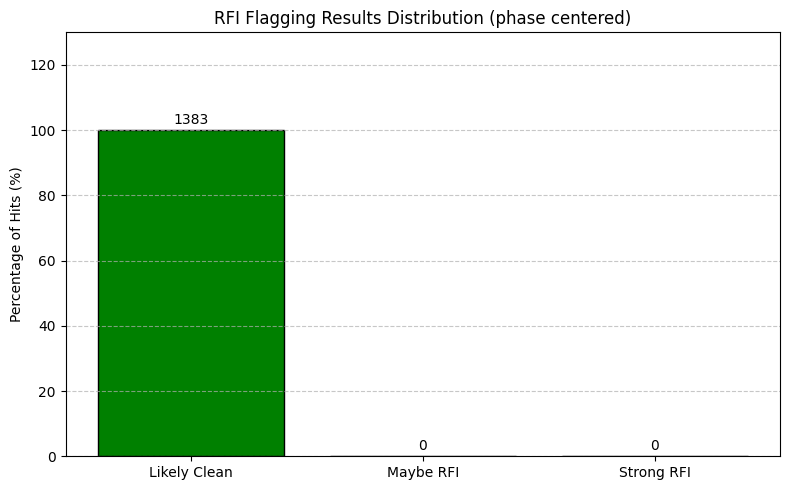

In [58]:

# Counts for each category
counts = {
    "Likely Clean": len(clean_meer_df),
    "Maybe RFI": len(maybe_rfi_meer_df),
    "Strong RFI": len(strong_rfi_meer_df)
}

total = sum(counts.values())

# Calculate percentages
percentages = {k: v / total * 100 for k, v in counts.items()}

# Plot percentages bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(percentages.keys(), percentages.values(), color=['green', 'orange', 'red'], edgecolor='black')
plt.ylabel('Percentage of Hits (%)')
plt.title('RFI Flagging Results Distribution (phase centered)')

# Add count labels above bars
for bar, key in zip(bars, percentages.keys()):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1, f"{counts[key]}", ha='center', va='bottom', fontsize=10)

plt.ylim(0, max(percentages.values()) * 1.3)  # add some space above bars
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
#non vlass pickle files 
#clean_df.to_pickle("clean_data/clean_non_vlass.pkl")
#maybe_rfi_df.to_pickle("clean_data/maybe_rfi_non_vlass.pkl")
maybe_rfi_unmatched_df.to_pickle("clean_data/maybe_rfi_unmatched_non_vlass.pkl")
clean_unmatched_df.to_pic   kle("clean_data/clean_unmatched_non_vlass.pkl")

In [ ]:
#vlass pickle files 
#clean_df.to_pickle("clean_data/clean_vlass.pkl")
#maybe_rfi_df.to_pickle("clean_data/maybe_rfi_vlass.pkl")
#maybe_rfi_unmatched_df.to_pickle("clean_data/maybe_rfi_unmatched_vlass.pkl")
#clean_unmatched_df.to_pickle("clean_data/clean_unmatched_vlass.pkl")

In [72]:
#non vlass
filename_clean = "clean_data/clean_non_vlass.pkl"
filename_maybe = "clean_data/maybe_rfi_non_vlass.pkl"
filename_clean_unmatched = "clean_data/clean_unmatched_non_vlass.pkl"
filename_maybe_unmatched = "clean_data/maybe_rfi_unmatched_non_vlass.pkl"

#vlass 
filename_clean_vlass = "clean_data/clean_vlass.pkl"
filename_maybe_vlass = "clean_data/maybe_rfi_vlass.pkl"
filename_clean_unmatched_vlass = "clean_data/clean_unmatched_vlass.pkl"
filename_maybe_unmatched_vlass = "clean_data/maybe_rfi_unmatched_vlass.pkl"

def append_to_pickle(filename, data):
    if os.path.exists(filename):
        existing_df = pd.read_pickle(filename)
        combined_df = pd.concat([existing_df, data], ignore_index=True)
    else:
        combined_df = data
    combined_df.to_pickle(filename)

#append_to_pickle(filename_clean, clean_df)
#append_to_pickle(filename_maybe, maybe_rfi_df)

#append_to_pickle(filename_clean_unmatched, clean_unmatched_df)
#append_to_pickle(filename_maybe_unmatched, maybe_rfi_unmatched_df)

#append_to_pickle(filename_clean_vlass, clean_df)
#append_to_pickle(filename_maybe_vlass, maybe_rfi_df)

append_to_pickle(filename_clean_unmatched_vlass, clean_unmatched_df)
append_to_pickle(filename_maybe_unmatched_vlass, maybe_rfi_unmatched_df)

In [64]:
import glob
import pandas as pd

# Initial hit count (absolute path)
print('initial hit count')
for file in glob.glob('/datax/scratch/ellambishop/test_refine/*.pkl'):
    df = pd.read_pickle(file)
    print(f"{file}: {len(df)} rows")

# Cleaned hit count (relative path from current directory)
print('\ncleaned hit count')
for file in glob.glob('clean_data/*.pkl'):
    df = pd.read_pickle(file)
    print(f"{file}: {len(df)} rows")



initial hit count
/datax/scratch/ellambishop/test_refine/vlass_incoherent.pkl: 77431 rows
/datax/scratch/ellambishop/test_refine/vlass_phase_center.pkl: 1426 rows
/datax/scratch/ellambishop/test_refine/vlass_other.pkl: 420344 rows
/datax/scratch/ellambishop/test_refine/non_vlass_incoherent.pkl: 1342625 rows
/datax/scratch/ellambishop/test_refine/non_vlass_phase_center.pkl: 845960 rows
/datax/scratch/ellambishop/test_refine/non_vlass_other.pkl: 1942776 rows

cleaned hit count
clean_data/clean_non_vlass.pkl: 592 rows
clean_data/maybe_rfi_non_vlass.pkl: 667374 rows
clean_data/clean_vlass.pkl: 110 rows
clean_data/maybe_rfi_vlass.pkl: 40092 rows
clean_data/maybe_rfi_unmatched_non_vlass.pkl: 157555 rows
clean_data/clean_unmatched_non_vlass.pkl: 33869 rows
clean_data/maybe_rfi_unmatched_vlass.pkl: 252700 rows
clean_data/clean_unmatched_vlass.pkl: 36261 rows


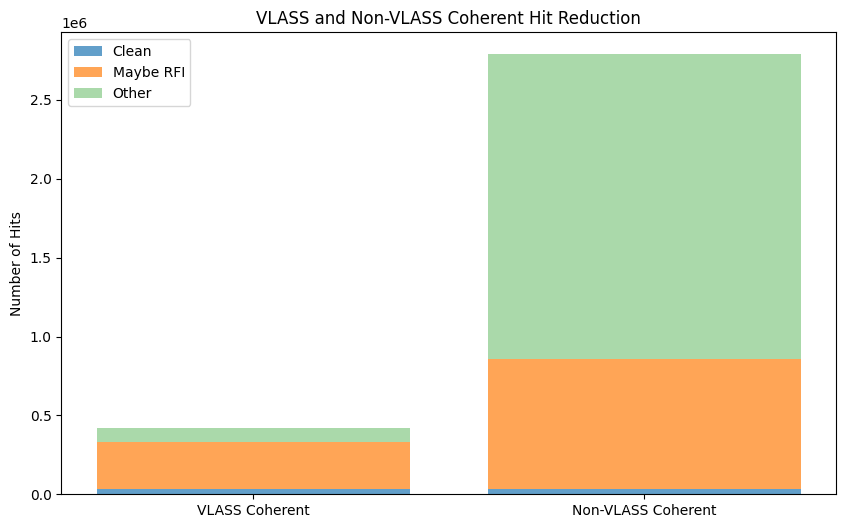

In [ ]:
import matplotlib.pyplot as plt

# Categories
categories = ["VLASS Coherent", "Non-VLASS Coherent"]

# Initial counts
initial = [1426+420344, 845960+1942776, ]  # total hits

# Cleaned counts (clean + unmatched clean)
clean = [110+36261, 592+33869]  # sum of clean + clean unmatched

# Maybe RFI counts (maybe_rfi + unmatched maybe)
maybe_rfi = [40092+252700, 667374+157555]

# Other (remaining hits not accounted in clean or maybe)
other = [initial[0] - (clean[0] + maybe_rfi[0]),
         initial[1] - (clean[1] + maybe_rfi[1])]

# Plot stacked bar
plt.figure(figsize=(10,6))
plt.bar(categories, clean, label='Clean', alpha=0.7)
plt.bar(categories, maybe_rfi, bottom=clean, label='Maybe RFI', alpha=0.7)
plt.bar(categories, other, bottom=[c+m for c,m in zip(clean, maybe_rfi)],
        label='Other', alpha=0.4)
plt.ylabel("Number of Hits")
plt.title("VLASS and Non-VLASS Coherent Hit Reduction")
plt.legend()
plt.show()


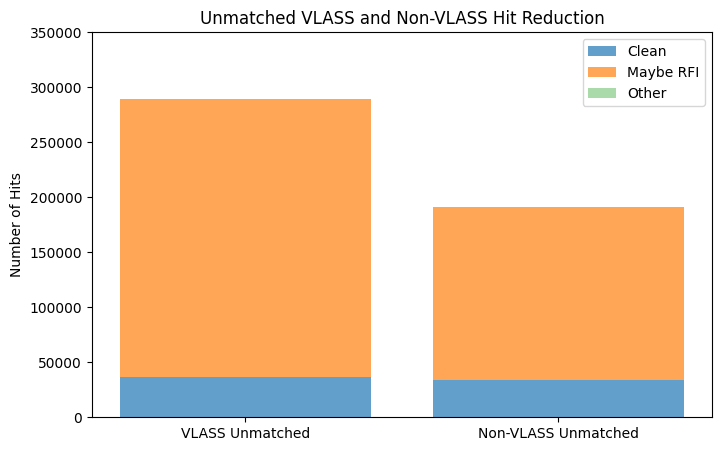

In [71]:
# 3️⃣ Unmatched
categories = ["VLASS Unmatched", "Non-VLASS Unmatched"]

# Initial counts for unmatched only
initial = [36261 + 252700, 33869 + 157555]

# Cleaned counts (only unmatched clean)
clean = [36261, 33869]

# Maybe RFI counts (only unmatched maybe_rfi)
maybe_rfi = [252700, 157555]

# Other (remaining hits not accounted in clean or maybe)
other = [initial[0] - (clean[0] + maybe_rfi[0]),
         initial[1] - (clean[1] + maybe_rfi[1])]

plt.figure(figsize=(8,5))
plt.bar(categories, clean, label='Clean', alpha=0.7)
plt.bar(categories, maybe_rfi, bottom=clean, label='Maybe RFI', alpha=0.7)
plt.bar(categories, other, bottom=[c+m for c,m in zip(clean, maybe_rfi)],
        label='Other', alpha=0.4)
plt.ylabel("Number of Hits")
plt.title("Unmatched VLASS and Non-VLASS Hit Reduction")
plt.ylim(0,350000)
plt.legend()
plt.savefig('unmatched_coh.jpg')